# Simulating a multi armed bandit

In [17]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [21]:
class Bandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)  # hidden
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        """Return a noisy reward for the chosen arm."""
        return np.random.normal(self.true_means[arm], 1.0)

bandit = Bandit(n_arms=10)
print("True arm means (hidden from agent):", np.round(bandit.true_means, 2))
print(f"Optimal arm: {bandit.optimal_arm} (mean={bandit.true_means[bandit.optimal_arm]:.2f})")

True arm means (hidden from agent): [-0.6   1.85 -0.01 -1.06  0.82 -1.22  0.21 -1.96 -1.33  0.2 ]
Optimal arm: 1 (mean=1.85)


In [28]:
def run_agent(bandit, policy, n_steps=1000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # pull counts
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean update
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

# --- Policies ---
def greedy(Q, N, t):          return np.argmax(Q)
def epsilon_greedy(eps):      return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
def ucb(c):                   return lambda Q, N, t: np.argmax(Q + c * np.sqrt(np.log(t+1) / (N+1e-9)))
def softmax(tau=0.5):         return lambda Q, N, t: np.random.choice(len(Q), p=(lambda e: e/e.sum())(np.exp((Q - Q.max())/tau)))

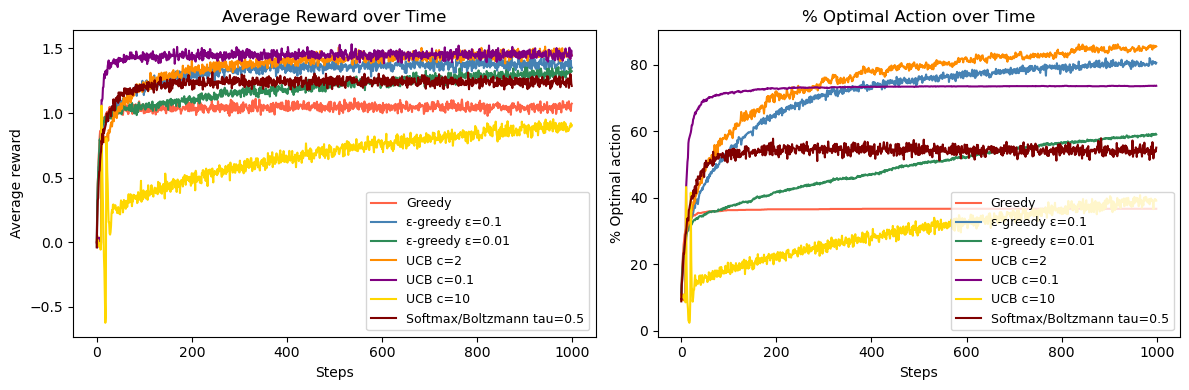

In [29]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',                     greedy,                'tomato'),
    ('ε-greedy ε=0.1',             epsilon_greedy(0.1),   'steelblue'),
    ('ε-greedy ε=0.01',            epsilon_greedy(0.01),  'seagreen'),
    ('UCB c=2',                    ucb(2),                'darkorange'),
    ('UCB c=0.1',                  ucb(0.1),              'purple'),
    ('UCB c=10',                   ucb(10),               'gold'),
    ('Softmax/Boltzmann tau=0.5',  softmax(0.5),          'maroon')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

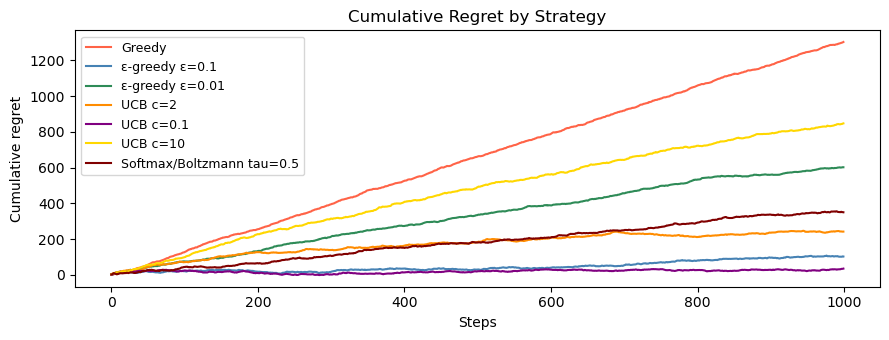

In [30]:
b = Bandit(n_arms=10)
best_mean = b.true_means.max()

plt.figure(figsize=(9, 3.5))
for label, policy, color in configs:
    b = Bandit(n_arms=10)
    # fix the same bandit for fair comparison
    b.true_means = np.array([0.2, -0.5, 1.2, 0.8, -0.1, 0.5, -0.8, 0.3, 1.5, 0.0])
    b.optimal_arm = np.argmax(b.true_means)
    best_mean = b.true_means.max()
    rewards, _ = run_agent(b, policy, N_STEPS)
    cumulative_regret = np.cumsum(best_mean - rewards)
    plt.plot(cumulative_regret, label=label, color=color, linewidth=1.5)
plt.xlabel('Steps'); plt.ylabel('Cumulative regret')
plt.title('Cumulative Regret by Strategy')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

# Results
### Greedy
Never explores, gets stuck early at mediocre rewards, regret grows fast early - may plateau or keep growing based on luck.  
### ε-greedy
ε=0.1:   Explores often, improves faster but plateaus below optimal because it keeps exploring even after learning.  
ε=0.01:  Rarely explores, starts slow but slowly improves as it occasionally discovers better arms.  
Regret grows linearly forever.  
### Upper Confidence Bound
Smartest policy, explores smartly and converges fast, regret grows logarithmically.  
c=0.1:   Rarely explores, almost identical to greedy.  
c=2.0:   Balanced exploration and exploitation.  
c=10.0:  Explores too much and wastes pulls on bad arms, slow to converge.  
### Softmax/Boltzmann
Typically performs close to ε-greedy ε=0.1 but with a smoother curve, regret grows quickly at first, then slows significantly.

# Non Stationary Bandit

In [37]:
class NonStationaryBandit:
    def __init__ns(self_ns, n_arms_ns=10):
        self.n_arms_ns = n_arms_ns
        self.true_means_ns = np.random.normal(0, 1, n_arms_ns)

    def pull_ns(self_ns, arm_ns):
        # Drift all true means slightly each step
        self.true_means_ns += np.random.normal(0, 0.01, self.n_arms_ns)
        self.optimal_arm_ns = np.argmax(self.true_means_ns)  # update optimal after drift
        return np.random.normal(self.true_means_ns[arm], 1.0)

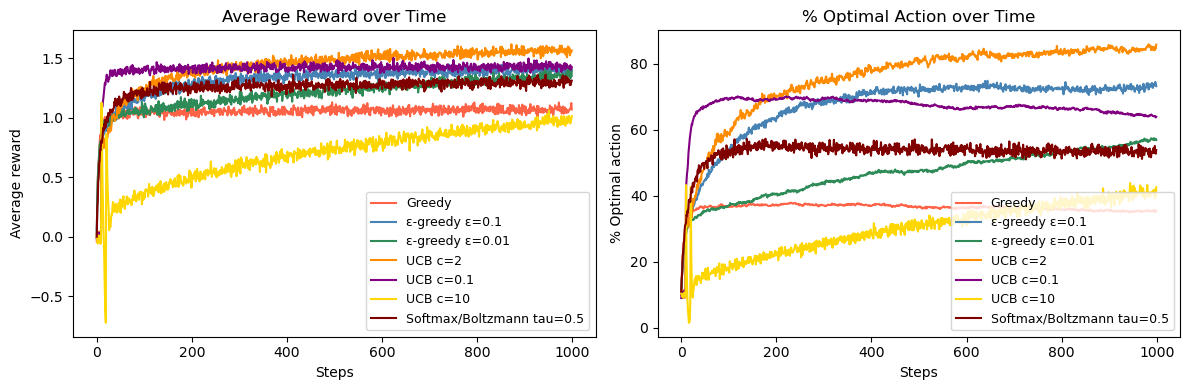

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards_ns   = np.zeros((N_RUNS, N_STEPS))
    all_optimal_ns   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b_ns = NonStationaryBandit(n_arms=10)
        r_ns, opt_ns = run_agent(b_ns, policy, N_STEPS)
        all_rewards_ns[run] = r_ns
        all_optimal_ns[run] = opt_ns
    axes[0].plot(all_rewards_ns.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal_ns.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# Results
The policies work worse with non stationary bandits than they did with stationary ones. This is because a lack of a recency weightage factor. They give the newer pulls the same weightage as the older ones despite the arms changing their true means.  
Their relative strength to each other remain more or less the same.